# 🧩 Self-Supervised Learning (SSL)

We previously explored Transfer Learning, where we reused the "pre-trained body" of a model (like ResNet or BERT). But how are those models initially trained? The answer lies in **Self-Supervised Learning (SSL)**.

### 1. What is Self-Supervised Learning?

SSL is a technique that allows a model to learn useful **feature representations** from massive amounts of **unlabeled data**.

* **Supervised Learning:** Requires explicit human-provided labels ($\mathbf{x} \rightarrow y$). (Image of a dog $\rightarrow$ "dog")
* **Unsupervised Learning:** Finds patterns in data without explicit labels (e.g., clustering).
* **Self-Supervised Learning:** Creates a pseudo-label $y'$ directly from the input data $\mathbf{x}$ itself, turning an unsupervised problem into a supervised one. This task is called the **Pretext Task**.

SSL teaches the model crucial general knowledge (e.g., orientation, context, semantics) without costly human annotation.

### 2. The Pretext Task

The key to SSL is designing a **Pretext Task** whose solution requires understanding high-level concepts.

* **In NLP (BERT):** The pretext task is **Masked Language Modeling (MLM)**—predicting a missing word in a sentence. This forces the model to understand syntax and context.
* **In CV (Rotation Prediction):** The pretext task is predicting the orientation of an image.

## 3. Practical Example: Rotation Prediction (RotNet)

We will implement a simple version of **RotNet**, where the model's objective is to determine whether an image has been rotated by 0°, 90°, 180°, or 270°.

**Input:** Image $x$.
**Target Label $y'$:**
* 0: 0° rotation
* 1: 90° rotation
* 2: 180° rotation
* 3: 270° rotation

Solving this forces the convolutional layers to learn concepts like "up," "down," and object orientation, which are fundamental for downstream classification tasks.

## 4. Setup and Data Preparation

We will use the CIFAR-10 dataset, but we will **ignore its original labels**. The labels for training will be generated by our custom transformation function.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Configuration
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Custom Dataset for Rotation Pretext Task ---
class RotationDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.rotations = [0, 90, 180, 270]

        # Standard normalization for image data
        self.base_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        # 1. Get the image (raw PIL image)
        img, _ = self.dataset[index]

        # 2. Select a random rotation angle index (0, 1, 2, or 3)
        rotation_label = torch.randint(0, 4, (1,)).item()
        angle = self.rotations[rotation_label]

        # 3. Apply the rotation transform
        rotated_img = transforms.functional.rotate(img, angle)

        # 4. Apply standard normalization
        x = self.base_transform(rotated_img)

        # x is the input, rotation_label is the self-generated pseudo-label
        return x, rotation_label

# Load base CIFAR-10 data (we only use the images, not the original labels)
base_cifar = datasets.CIFAR10(root='./data', train=True, download=True)
ssl_dataset = RotationDataset(base_cifar)
ssl_loader = DataLoader(ssl_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Dataset size: {len(ssl_dataset)}")

Using device: cuda
Dataset size: 50000


## 5. Model Architecture for the Pretext Task

We use a simple Convolutional Neural Network (CNN) backbone.

**Key Difference:** The final layer must output **4 classes** (0, 90, 180, 270) instead of the original 10 classes of CIFAR-10.

In [3]:
class SSLModel(nn.Module):
    def __init__(self, num_output_classes=4):
        super().__init__()
        # --- Feature Extractor (The backbone we want to pre-train) ---
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 16x16

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 8x8

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 4x4
            nn.Flatten()
        )

        # Calculate the size of the flattened output: 128 * 4 * 4 = 2048

        # --- Pretext Head (Classification Head for the Pretext Task) ---
        self.pretext_head = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Linear(512, num_output_classes) # 4 outputs for 4 rotations
        )

    def forward(self, x):
        features = self.features(x)
        output = self.pretext_head(features)
        return output

# Initialize
ssl_model = SSLModel().to(device)
print(f"Model initialized with {sum(p.numel() for p in ssl_model.parameters()):,} total parameters.")

Model initialized with 1,144,388 total parameters.


## 6. Training the Pretext Task

We train the model using standard supervised learning techniques, but remember, the "labels" are generated by the rotations we applied, not the original CIFAR-10 labels.

In [4]:
optimizer = optim.Adam(ssl_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

print(f"Starting SSL Pretext Training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):
    ssl_model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for inputs, labels in ssl_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = ssl_model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | Rotation Loss: {epoch_loss:.4f} Rotation Acc: {epoch_acc:.4f}')

print("\nPretext Training complete. Features are now learned!")

Starting SSL Pretext Training for 10 epochs...
Epoch 1/10 | Rotation Loss: 1.0119 Rotation Acc: 0.5750
Epoch 2/10 | Rotation Loss: 0.8676 Rotation Acc: 0.6472
Epoch 3/10 | Rotation Loss: 0.7918 Rotation Acc: 0.6805
Epoch 4/10 | Rotation Loss: 0.7407 Rotation Acc: 0.7037
Epoch 5/10 | Rotation Loss: 0.6945 Rotation Acc: 0.7232
Epoch 6/10 | Rotation Loss: 0.6586 Rotation Acc: 0.7402
Epoch 7/10 | Rotation Loss: 0.6279 Rotation Acc: 0.7544
Epoch 8/10 | Rotation Loss: 0.5938 Rotation Acc: 0.7693
Epoch 9/10 | Rotation Loss: 0.5636 Rotation Acc: 0.7802
Epoch 10/10 | Rotation Loss: 0.5432 Rotation Acc: 0.7903

Pretext Training complete. Features are now learned!


## 7. Evaluating the Feature Extractor

The primary goal of SSL is not to predict rotation, but to create a high-quality **feature extractor** (the `ssl_model.features` part).

We can now use the learned `features` module as a pre-trained backbone for a new, supervised task.

### The Downstream Supervised Task
If we want to classify the original 10 CIFAR-10 classes, we need to:
1.  **Freeze** the `ssl_model.features` (the learned backbone).
2.  **Replace** the `pretext_head` with a new `downstream_head` (10 outputs).
3.  **Train** *only* the new head using the original CIFAR-10 labels.

The features learned during the rotation task significantly accelerate the training of the final classification layer.

In [6]:
# --- Creating the Downstream Classifier ---
class DownstreamClassifier(nn.Module):
    def __init__(self, learned_features, num_classes=10):
        super().__init__()

        # 1. Use the learned Feature Extractor (Backbone)
        self.features = learned_features

        # 2. Freeze the learned weights (Strategy 1: Fixed Feature Extractor)
        for param in self.features.parameters():
            param.requires_grad = False

        # 3. Define the new Downstream Head (for the original 10 classes)
        self.downstream_head = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes) # 10 outputs for CIFAR-10
        )

    def forward(self, x):
        features = self.features(x)
        output = self.downstream_head(features)
        return output

# Instantiate the final classifier
final_classifier = DownstreamClassifier(ssl_model.features).to(device)

# --- Sanity Check ---
trainable_params = sum(p.numel() for p in final_classifier.parameters() if p.requires_grad)

print("\n--- Downstream Classifier Status ---")
print(f"Original Feature Extractor (Backbone) is frozen.")
print(f"Trainable Parameters (New Head only): {trainable_params:,}")

print("Classifier ready for the supervised CIFAR-10 classification task.")


--- Downstream Classifier Status ---
Original Feature Extractor (Backbone) is frozen.
Trainable Parameters (New Head only): 1,054,218
Classifier ready for the supervised CIFAR-10 classification task.


## 8. Training the Downstream Classifier

Now, we will train our `DownstreamClassifier` which uses the frozen feature extractor from the SSL pretext task. We will train only the `downstream_head` using the original CIFAR-10 labels.

In [7]:
# --- Prepare Data for Downstream Task (CIFAR-10 with original labels) ---

# Standard transformation for CIFAR-10 (same as base_transform in RotationDataset)
downstream_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load original CIFAR-10 training and test datasets
cifar_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=downstream_transform)
cifar_test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=downstream_transform)

cifar_train_loader = DataLoader(cifar_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
cifar_test_loader = DataLoader(cifar_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"CIFAR-10 Training dataset size: {len(cifar_train_dataset)}")
print(f"CIFAR-10 Test dataset size: {len(cifar_test_dataset)}")

CIFAR-10 Training dataset size: 50000
CIFAR-10 Test dataset size: 10000


In [8]:
# --- Training loop for the Downstream Classifier ---

downstream_optimizer = optim.Adam(final_classifier.downstream_head.parameters(), lr=LEARNING_RATE)
downstream_criterion = nn.CrossEntropyLoss()

NUM_DOWNSTREAM_EPOCHS = 10

print(f"Starting Downstream Classification Training for {NUM_DOWNSTREAM_EPOCHS} epochs...")

for epoch in range(NUM_DOWNSTREAM_EPOCHS):
    final_classifier.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for inputs, labels in cifar_train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        downstream_optimizer.zero_grad()

        outputs = final_classifier(inputs)
        _, preds = torch.max(outputs, 1)
        loss = downstream_criterion(outputs, labels)

        loss.backward()
        downstream_optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples

    print(f'Epoch {epoch+1}/{NUM_DOWNSTREAM_EPOCHS} | CIFAR-10 Loss: {epoch_loss:.4f} CIFAR-10 Acc: {epoch_acc:.4f}')

print("\nDownstream Training complete!")

Starting Downstream Classification Training for 10 epochs...
Epoch 1/10 | CIFAR-10 Loss: 1.0522 CIFAR-10 Acc: 0.6337
Epoch 2/10 | CIFAR-10 Loss: 0.8179 CIFAR-10 Acc: 0.7152
Epoch 3/10 | CIFAR-10 Loss: 0.7066 CIFAR-10 Acc: 0.7528
Epoch 4/10 | CIFAR-10 Loss: 0.6072 CIFAR-10 Acc: 0.7884
Epoch 5/10 | CIFAR-10 Loss: 0.5003 CIFAR-10 Acc: 0.8277
Epoch 6/10 | CIFAR-10 Loss: 0.3994 CIFAR-10 Acc: 0.8684
Epoch 7/10 | CIFAR-10 Loss: 0.3026 CIFAR-10 Acc: 0.9073
Epoch 8/10 | CIFAR-10 Loss: 0.2180 CIFAR-10 Acc: 0.9389
Epoch 9/10 | CIFAR-10 Loss: 0.1479 CIFAR-10 Acc: 0.9638
Epoch 10/10 | CIFAR-10 Loss: 0.0988 CIFAR-10 Acc: 0.9809

Downstream Training complete!


## 9. Evaluation of Downstream Classifier

Let's evaluate the performance of our `DownstreamClassifier` on the CIFAR-10 test set. This will show how well the features learned from the self-supervised pretext task generalize to a new, supervised classification task.

In [9]:
# --- Evaluate the Downstream Classifier ---

final_classifier.eval() # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in cifar_test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = final_classifier(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the Downstream Classifier on the 10000 test images: {accuracy:.2f}%')

Accuracy of the Downstream Classifier on the 10000 test images: 71.66%


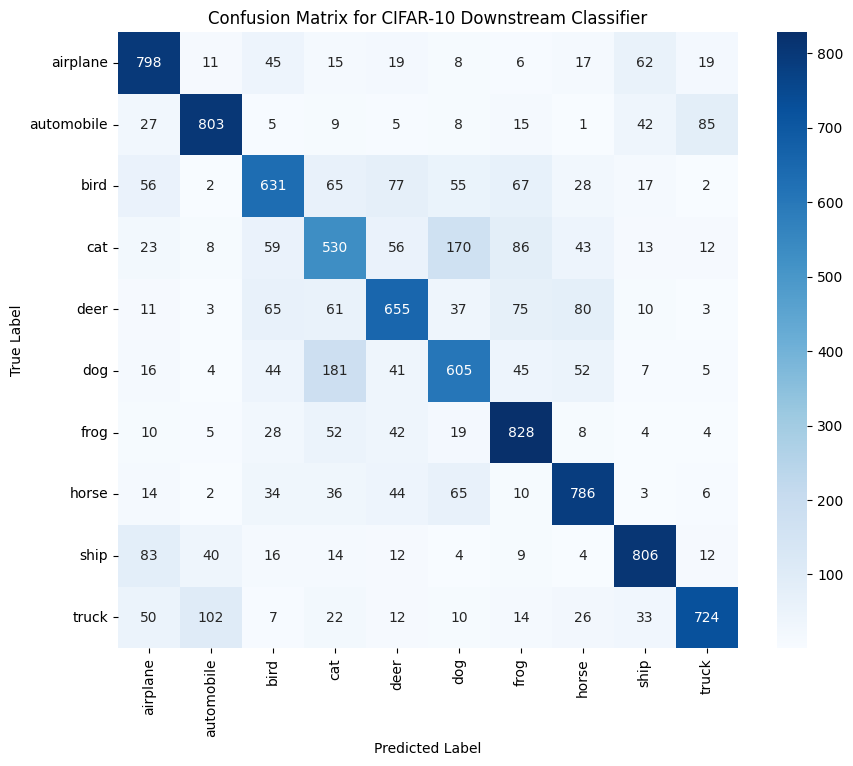

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get all predictions and true labels for the test set
all_preds = []
all_labels = []

final_classifier.eval()
with torch.no_grad():
    for inputs, labels in cifar_test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = final_classifier(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Define CIFAR-10 class names for better visualization
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cifar10_classes, yticklabels=cifar10_classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CIFAR-10 Downstream Classifier')
plt.show()

## 10. Conclusion

**Self-Supervised Learning** is the foundation of modern high-performance models like BERT and large Vision Transformers.

By creating a clever **Pretext Task** (like predicting image rotation), we forced the model to learn meaningful visual representations (edges, orientation, object parts) from **unlabeled data**.

This learned representation can then be efficiently transferred to specific downstream supervised tasks, combining the power of vast unlabeled data with the precision of labeled data—the core mechanism behind the "Pre-train, Fine-tune" paradigm.